In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("customer_personality_raw.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (31, 10)


,CustomerID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Country,Spent
0,1001,1985,Graduation,Single,45000.0,0.0,1,15-01-2024,India,650
1,1002,1972,PhD,Married,72000.0,1.0,1,22-02-2024,India,980
2,1003,1990,graduation,Single,38000.0,0.0,0,05-03-2024,India,420
3,1004,1982,Master,Married,61000.0,1.0,0,18-03-2024,India,760
4,1005,1978,PhD,Divorced,55000.0,0.0,1,27-03-2024,India,810


In [9]:
print("DATASET INFORMATION")
print("=" * 40)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

DATASET INFORMATION
Rows: 31
Columns: 10

Column Names:
['CustomerID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Country', 'Spent']

Data Types:
CustomerID          int64
Year_Birth          int64
Education          object
Marital_Status     object
Income            float64
Kidhome           float64
Teenhome            int64
Dt_Customer        object
Country            object
Spent               int64
dtype: object


In [10]:
missing_before = df.isnull().sum().sum()
duplicates_before = df.duplicated().sum()

print("DATA QUALITY BEFORE CLEANING")
print("=" * 40)

print("Total Missing Values:", missing_before)
print("Duplicate Rows:", duplicates_before)

print("\nMissing Values by Column:")
print(df.isnull().sum())

DATA QUALITY BEFORE CLEANING
Total Missing Values: 3
Duplicate Rows: 2

Missing Values by Column:
CustomerID        0
Year_Birth        0
Education         0
Marital_Status    0
Income            2
Kidhome           1
Teenhome          0
Dt_Customer       0
Country           0
Spent             0
dtype: int64


In [11]:
# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing numerical values with median
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Standardize text values
for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

# Convert date column to datetime
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    dayfirst=True,
    errors="coerce"
)

# Convert selected columns to integer
integer_cols = ["CustomerID", "Year_Birth", "Kidhome", "Teenhome"]

for col in integer_cols:
    df[col] = df[col].astype(int)

print("Data cleaning completed successfully!")

Data cleaning completed successfully!


In [12]:
missing_after = df.isnull().sum().sum()
duplicates_after = df.duplicated().sum()

print("DATA QUALITY AFTER CLEANING")
print("=" * 40)

print("Total Missing Values:", missing_after)
print("Duplicate Rows:", duplicates_after)

print("\nData Types:")
print(df.dtypes)

DATA QUALITY AFTER CLEANING
Total Missing Values: 0
Duplicate Rows: 0

Data Types:
CustomerID                 int32
Year_Birth                 int32
Education                 object
Marital_Status            object
Income                   float64
Kidhome                    int32
Teenhome                   int32
Dt_Customer       datetime64[ns]
Country                   object
Spent                      int64
dtype: object


In [13]:
rows_before = 31
rows_after = len(df)

quality_report = pd.DataFrame({
    "Metric": [
        "Rows",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Before Cleaning": [
        rows_before,
        missing_before,
        duplicates_before
    ],
    "After Cleaning": [
        rows_after,
        missing_after,
        duplicates_after
    ]
})

quality_report

,Metric,Before Cleaning,After Cleaning
0,Rows,31,29
1,Missing Values,3,0
2,Duplicate Rows,2,0


In [14]:
print("CLEANED DATASET")
print("=" * 40)

df.head(10)

CLEANED DATASET


,CustomerID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Country,Spent
0,1001,1985,Graduation,Single,45000.0,0,1,2024-01-15,India,650
1,1002,1972,Phd,Married,72000.0,1,1,2024-02-22,India,980
2,1003,1990,Graduation,Single,38000.0,0,0,2024-03-05,India,420
3,1004,1982,Master,Married,61000.0,1,0,2024-03-18,India,760
4,1005,1978,Phd,Divorced,55000.0,0,1,2024-03-27,India,810
5,1006,1988,Graduation,Single,55000.0,0,0,2024-04-02,India,390
6,1007,1975,Master,Married,68000.0,1,1,2024-04-14,India,920
7,1008,1992,Graduation,Single,41000.0,0,0,2024-04-29,India,350
8,1009,1980,Phd,Married,76000.0,2,1,2024-05-10,India,1100
9,1010,1986,Master,Single,47000.0,0,1,2024-05-25,India,510


In [15]:
print("Education Values:")
print(df["Education"].unique())

print("\nCountry Values:")
print(df["Country"].unique())

print("\nMarital Status Values:")
print(df["Marital_Status"].unique())

Education Values:
['Graduation' 'Phd' 'Master']

Country Values:
['India']

Marital Status Values:
['Single' 'Married' 'Divorced']


In [16]:
df.to_csv("customer_personality_cleaned.csv", index=False)

print("Cleaned dataset saved as:")
print("customer_personality_cleaned.csv")

Cleaned dataset saved as:
customer_personality_cleaned.csv


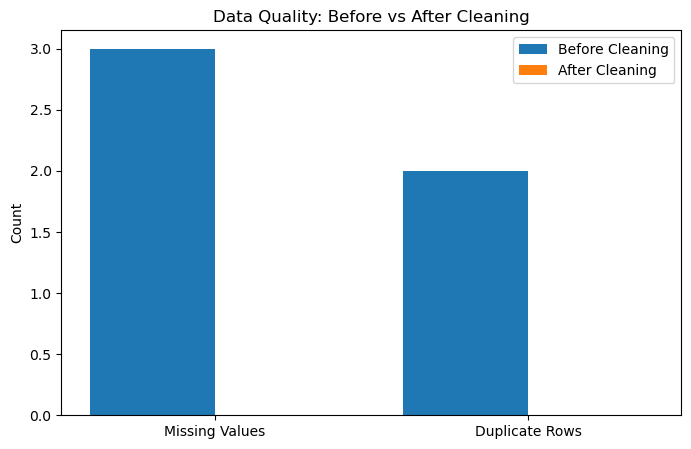

In [17]:
metrics = ["Missing Values", "Duplicate Rows"]

before = [missing_before, duplicates_before]
after = [missing_after, duplicates_after]

x = range(len(metrics))

plt.figure(figsize=(8, 5))

plt.bar([i - 0.2 for i in x], before, width=0.4, label="Before Cleaning")
plt.bar([i + 0.2 for i in x], after, width=0.4, label="After Cleaning")

plt.xticks(x, metrics)
plt.ylabel("Count")
plt.title("Data Quality: Before vs After Cleaning")
plt.legend()
plt.show()

In [18]:
print("=" * 50)
print("       DATA CLEANING PROJECT SUMMARY")
print("=" * 50)

print(f"Original Rows       : {rows_before}")
print(f"Final Rows          : {rows_after}")
print(f"Missing Values      : {missing_before} → {missing_after}")
print(f"Duplicate Rows      : {duplicates_before} → {duplicates_after}")

print("\nCleaning Operations:")
print("✓ Missing values handled")
print("✓ Duplicate records removed")
print("✓ Text values standardized")
print("✓ Extra spaces removed")
print("✓ Date converted to datetime")
print("✓ Data types corrected")

print("\nOutput File:")
print("customer_personality_cleaned.csv")

print("\nStatus: Dataset is clean and ready for analysis.")

       DATA CLEANING PROJECT SUMMARY
Original Rows       : 31
Final Rows          : 29
Missing Values      : 3 → 0
Duplicate Rows      : 2 → 0

Cleaning Operations:
✓ Missing values handled
✓ Duplicate records removed
✓ Text values standardized
✓ Extra spaces removed
✓ Date converted to datetime
✓ Data types corrected

Output File:
customer_personality_cleaned.csv

Status: Dataset is clean and ready for analysis.
